#### Modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

#### Use GPU for calculation

Please use your GPU, do not wast your time on the stupid CPU

In [3]:
# Select device - supports NVIDIA CUDA, Apple Metal (M-chips), or CPU fallback
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_type = "NVIDIA CUDA"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    device_type = "Apple Metal (M-chip)"
else:
    device = torch.device("cpu")
    device_type = "CPU"

print(f"Using device: {device} ({device_type})")

Using device: cuda (NVIDIA CUDA)


#### Train and testing splits 

Stratify ensures training, validation and testing datasets have the exact same proportion of crack and uncrack as the original dataset

In [4]:
# Load datasets
df_walls = pd.read_pickle('wall_data_cleaned.pkl')
df_decks = pd.read_pickle('deck_data_cleaned.pkl')

# Split the Walls DataFrame (15% of total wall data for validation, hence 0.15 / 0.85 ≈ 0.176 for second split)
walls, walls_te = train_test_split(df_walls, test_size=0.2, random_state=42, stratify=df_walls['Label'])
walls_tr, walls_val = train_test_split(walls, test_size=0.176, random_state=42, stratify=walls['Label'])

# Split the Decks DataFrame
decks, decks_te = train_test_split(df_decks, test_size=0.2, random_state=42, stratify=df_decks['Label'])
decks_tr, decks_val = train_test_split(decks, test_size=0.176, random_state=42, stratify=decks['Label'])

#### CNN Architecture

The network consists of 4 convolution layers and 3 hidden layers to be trained. The filters extract features in the image and pass the filter data to the neural network to perform classification.

In [5]:
class CNNBinary(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Adding padding=1 and BatchNorm2d
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Replaced Flatten with AdaptiveAvgPool2d
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Input is now just 256, drastically reducing parameters
            nn.Linear(256, 128), 
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)       # Global Average Pooling
        x = self.classifier(x)
        return x


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = deepcopy(model.state_dict())
            return False

        self.counter += 1
        return self.counter >= self.patience

label_map = {'Non-Cracked': 0.0, 'Cracked': 1.0}

#### Data Generator (Memory Efficient)

Instead of loading all images into memory at once, which causes the RAM TO EXPLODE, use a generator that loads images in batches to RAM during training.

In [6]:
# Custom PyTorch dataset (memory efficient)
class CrackDataset(Dataset):
    def __init__(self, dataframe, label_map):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = row['ImageData'].astype(np.float32) / 255.0
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)

        image = np.transpose(image, (2, 0, 1))
        x = torch.from_numpy(image)
        y = torch.tensor(self.label_map[row['Label']], dtype=torch.float32)

        return x, y

#### Training phase

1. Use adam as gradient decent computation

2. First train on training dataset to optimize the parameters in filters and hidden layers

3. The criterion_loss is the POS Loss Function computed earlier, which is distinct for each dataset

4. Next, use validation set to track the training process so that the model is not over trained on too much epoch.

5. The early stop is going to stop the training once F1 score of the model cease to decrease after 5 epoches (controlled using patience)

In [7]:
model_walls = CNNBinary().to(device)
model_decks = CNNBinary().to(device)

optimizer_walls = optim.Adam(model_walls.parameters(), lr=1e-4)
optimizer_decks = optim.Adam(model_decks.parameters(), lr=1e-4)

def train_model(model, train_loader, val_loader, optimizer, criterion_loss, device, epochs=300, patience=5, scheduler=None):
    
    # Early stopping based on F1 score instead of loss
    early_stopper = EarlyStopping(patience=patience)
    history = {"train_loss": [], "train_acc": [], "train_f1": [],
               "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}
    best_f1_val = 0.0
    
    # Training phase
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_train_preds = []
        all_train_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            # Compute loss function (logits is prediction probability, labels is ground truth) 
            optimizer.zero_grad()
            logits = model(images).squeeze(1)
            loss = criterion_loss(logits, labels)
            # Gradient backpropagation and optimization step
            loss.backward()
            # For MPS backend on Apple Silicon, use synchronize to ensure proper gradient updates
            if device.type == "mps":
                torch.mps.synchronize()
            # Use predicted probability (logits) to calculate training loss
            optimizer.step()
            running_loss += loss.item() * labels.size(0)
            # Use threshold of 0.5 to determine predicted class
            preds = (torch.sigmoid(logits) >= 0.5).float()
            # Predicted label compared to truth label for accuracy calculation
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            # Store predictions and labels for metrics calculation
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(all_train_labels, all_train_preds, zero_division=0)
        train_recall = recall_score(all_train_labels, all_train_preds, zero_division=0)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                # Use probability to calculate training loss (logits) and use threshold of 0.5 to determine predicted class
                logits = model(images).squeeze(1)
                loss = criterion_loss(logits, labels)
                # Assign prediction label based on predicted probability (logits) and threshold
                val_running_loss += loss.item() * labels.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                # Store predictions and labels for metrics calculation
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        # Calculate training validation metrics (loss, accuracy, F1 score)
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_val_labels, all_val_preds, zero_division=0)
        val_recall = recall_score(all_val_labels, all_val_preds, zero_division=0)
        
        if scheduler is not None:
            # ReduceLROnPlateau expects a monitored metric
            scheduler.step(val_f1)

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["lr"].append(current_lr)
        print(f"Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f}, train_f1: {train_f1:.4f}, train_recall:{train_recall:.4f} | "
              f"val_loss: {val_loss:.4f}, val_f1: {val_f1:.4f}, val_recall:{val_recall:.4f} | "
              f"lr: {current_lr:.6f}")

        # Early stopping based on F1 score
        if val_f1 > best_f1_val:
            best_f1_val = val_f1
            early_stopper.best_state = deepcopy(model.state_dict())
            early_stopper.counter = 0
        else:
            early_stopper.counter += 1
            if early_stopper.counter >= patience:
                print("Early stopping triggered (F1 score not improving).")
                break
        
    if early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)

    return history

#### POS weight for loss function

This is the weight assigned to each class in the loss function so that the penality for wrong prediction of minor class is more heavily penalize in the loss function. The value depends on the ratio between majority and minority

In [8]:
def calculate_pos_weight(dataframe, label_map):
    labels = dataframe['Label'].map(label_map).values
    num_neg = (labels == 0).sum()
    num_pos = (labels == 1).sum()
    if num_pos == 0:
        return torch.tensor(1.0)
    pos_weight = num_neg / num_pos
    return torch.tensor(pos_weight, dtype=torch.float32)

In [9]:
# Create data loaders for Walls dataset (memory efficient)
train_ds_walls = CrackDataset(walls_tr, label_map)
val_ds_walls = CrackDataset(walls_val, label_map)
test_ds_walls = CrackDataset(walls_te, label_map)

# pos_weight for Walls training set
pos_weight_walls = calculate_pos_weight(walls_tr, label_map)
criterion_bce_weighted_walls = nn.BCEWithLogitsLoss(pos_weight=pos_weight_walls.to(device))
print(f"Walls pos_weight: {pos_weight_walls.item():.4f}")

# pin_memory optimization is specific to NVIDIA CUDA (not applicable to MPS or CPU)
pin_memory = torch.cuda.is_available()
train_loader_walls = DataLoader(train_ds_walls, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader_walls = DataLoader(val_ds_walls, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_walls = DataLoader(test_ds_walls, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

Walls pos_weight: 7.0158


In [10]:
# Create data loaders for Decks dataset (memory efficient)
train_ds_decks = CrackDataset(decks_tr, label_map)
val_ds_decks = CrackDataset(decks_val, label_map)
test_ds_decks = CrackDataset(decks_te, label_map)

# pos_weight for Decks training set
pos_weight_decks = calculate_pos_weight(decks_tr, label_map)
criterion_bce_weighted_decks = nn.BCEWithLogitsLoss(pos_weight=pos_weight_decks.to(device))
print(f"Decks pos_weight: {pos_weight_decks.item():.4f}")

# pin_memory optimization is specific to NVIDIA CUDA (not applicable to MPS or CPU)
pin_memory = torch.cuda.is_available()
train_loader_decks = DataLoader(train_ds_decks, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader_decks = DataLoader(val_ds_decks, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_decks = DataLoader(test_ds_decks, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

Decks pos_weight: 6.6758


In [11]:
print("Wall ModelTraining with Weighted Loss (BCE with pos_weight)...\n")
scheduler_walls = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_walls, mode='max', factor=0.5, patience=2, min_lr=1e-6)

history_walls = train_model(
    model_walls,
    train_loader_walls,
    val_loader_walls,
    optimizer_walls,
    criterion_bce_weighted_walls,
    device,
    epochs=300,
    patience=5,
    scheduler=scheduler_walls)

Wall ModelTraining with Weighted Loss (BCE with pos_weight)...

Epoch 1/300 - train_loss: 1.0867, train_f1: 0.3249, train_recall:0.7697 | val_loss: 0.9564, val_f1: 0.3979, val_recall:0.8000 | lr: 0.000100
Epoch 2/300 - train_loss: 0.9036, train_f1: 0.4036, train_recall:0.8162 | val_loss: 0.8857, val_f1: 0.3623, val_recall:0.9228 | lr: 0.000100
Epoch 3/300 - train_loss: 0.8472, train_f1: 0.4279, train_recall:0.8185 | val_loss: 0.9104, val_f1: 0.5556, val_recall:0.5088 | lr: 0.000100
Epoch 4/300 - train_loss: 0.7930, train_f1: 0.4381, train_recall:0.8380 | val_loss: 0.7863, val_f1: 0.3918, val_recall:0.9368 | lr: 0.000100
Epoch 5/300 - train_loss: 0.7522, train_f1: 0.4668, train_recall:0.8215 | val_loss: 1.1378, val_f1: 0.3217, val_recall:0.9544 | lr: 0.000100
Epoch 6/300 - train_loss: 0.7175, train_f1: 0.4777, train_recall:0.8245 | val_loss: 1.5846, val_f1: 0.2973, val_recall:0.9895 | lr: 0.000050
Epoch 7/300 - train_loss: 0.6482, train_f1: 0.5259, train_recall:0.8447 | val_loss: 0.5833

In [12]:
print("Deck ModelTraining with Weighted Loss (BCE with pos_weight)...\n")
scheduler_decks = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_decks, mode='max', factor=0.5, patience=2, min_lr=1e-6)

history_decks = train_model(
    model_decks,
    train_loader_decks,
    val_loader_decks,
    optimizer_decks,
    criterion_bce_weighted_decks,
    device,
    epochs=300,
    patience=5,
    scheduler=scheduler_decks)

Deck ModelTraining with Weighted Loss (BCE with pos_weight)...

Epoch 1/300 - train_loss: 1.1687, train_f1: 0.2900, train_recall:0.7119 | val_loss: 1.1225, val_f1: 0.3423, val_recall:0.4733 | lr: 0.000100
Epoch 2/300 - train_loss: 1.0821, train_f1: 0.3286, train_recall:0.7551 | val_loss: 1.0402, val_f1: 0.3737, val_recall:0.6091 | lr: 0.000100
Epoch 3/300 - train_loss: 1.0165, train_f1: 0.3425, train_recall:0.7727 | val_loss: 1.1774, val_f1: 0.3493, val_recall:0.3004 | lr: 0.000100
Epoch 4/300 - train_loss: 1.0000, train_f1: 0.3611, train_recall:0.7445 | val_loss: 1.0038, val_f1: 0.3284, val_recall:0.9053 | lr: 0.000100
Epoch 5/300 - train_loss: 0.9613, train_f1: 0.3805, train_recall:0.7445 | val_loss: 0.9508, val_f1: 0.3338, val_recall:0.9177 | lr: 0.000050
Epoch 6/300 - train_loss: 0.9277, train_f1: 0.3920, train_recall:0.7330 | val_loss: 0.8954, val_f1: 0.4516, val_recall:0.6914 | lr: 0.000050
Epoch 7/300 - train_loss: 0.9170, train_f1: 0.4039, train_recall:0.7348 | val_loss: 0.9660

#### Evaluation Metrics - Recall, Precision, Confusion Matrix

Test Set Evaluation - Walls Dataset

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.96      0.94      0.95      2838
     Cracked       0.62      0.70      0.66       404

    accuracy                           0.91      3242
   macro avg       0.79      0.82      0.80      3242
weighted avg       0.92      0.91      0.91      3242



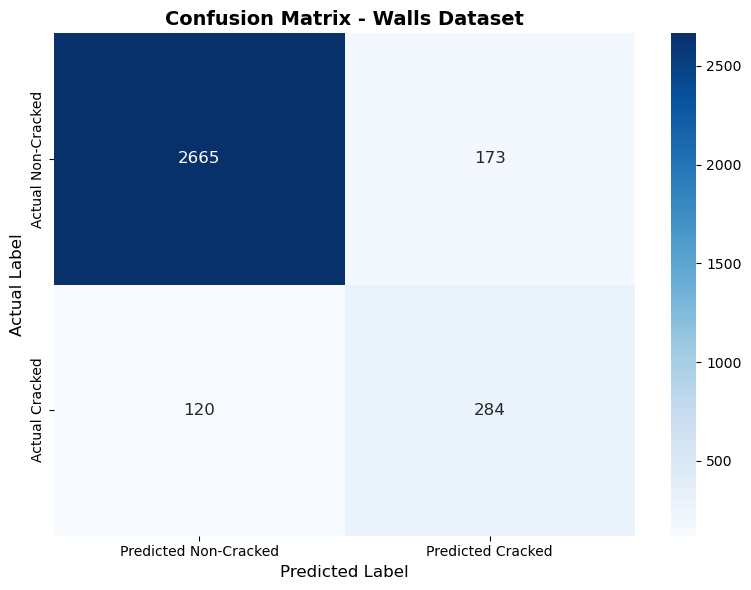

Test Set Evaluation - Decks Dataset

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.92      0.97      0.94      2300
     Cracked       0.68      0.46      0.55       344

    accuracy                           0.90      2644
   macro avg       0.80      0.71      0.75      2644
weighted avg       0.89      0.90      0.89      2644



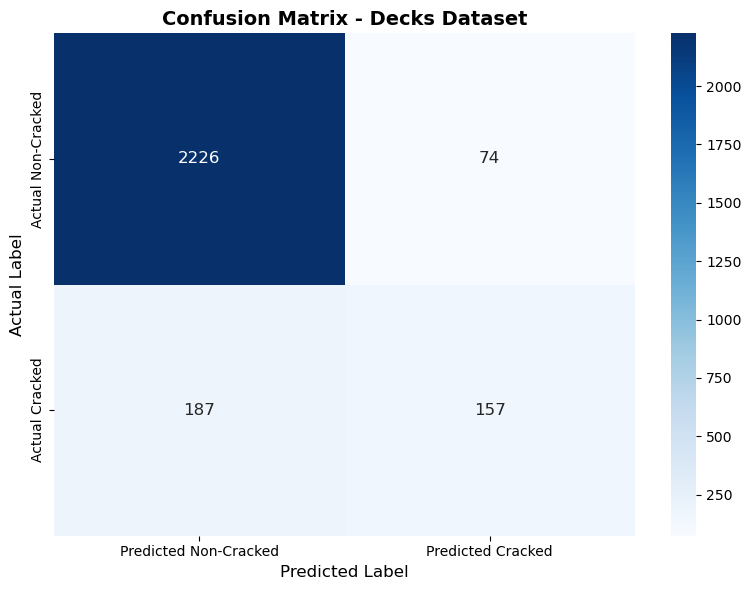

In [13]:
# Function to evaluate model on test set and compute metrics (recall, precision, confusion matrix)
def evaluate_model(model, test_loader, device, threshold=0.5, dataset_name=""):
    # Evaluate model and compute recall, precision, confusion matrix
    model.eval()
    all_preds = []
    all_labels = []
    # Same logic as before to find the predicted label and acutal label
    # Use threshold to determine predicted class (0.5 is default for binary classification)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images).squeeze(1)
            preds = (torch.sigmoid(logits) >= threshold).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Compute confusion matrix and show classification report (precision, recall, F1-score and etc)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['Non-Cracked', 'Cracked'],output_dict=True)
    print(f"Test Set Evaluation - {dataset_name}")
    print(f"\nClassification Report:\n{classification_report(all_labels, all_preds, target_names=['Non-Cracked', 'Cracked'])}")
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Predicted Non-Cracked', 'Predicted Cracked'],
                yticklabels=['Actual Non-Cracked', 'Actual Cracked'],
                annot_kws={'size': 12})
    plt.title(f'Confusion Matrix - {dataset_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    return cm, report, all_preds, all_labels


# Evaluate both models on test sets(use threshold of 0.5 for initial evaluation)
cm_walls, report_walls, preds_walls, labels_walls = evaluate_model(model_walls, test_loader_walls, device, threshold=0.5, dataset_name="Walls Dataset")
cm_decks, report_decks, preds_decks, labels_decks = evaluate_model(model_decks, test_loader_decks, device, threshold=0.5, dataset_name="Decks Dataset")

#### Save models and metadata for phase 3, finding out shit images from dataset

In [14]:
# Save the trained models
torch.save(model_walls.state_dict(), 'model_walls_cleaned.pth')
torch.save(model_decks.state_dict(), 'model_decks_cleaned.pth')

#### Low-Confidence Images (probability ≈ 0.5)

Images where the model's sigmoid output is close to 0.5 are those the model is most uncertain about. These are worth inspecting — they may represent ambiguous cracks, unusual lighting, or remaining label noise in the cleaned dataset.

In [ ]:
def show_low_confidence_images(model, df_test, device, tolerance=0.1, n_show=10, dataset_name=""):
    """Display test images where the model's predicted probability is within `tolerance` of 0.5,
    break them down into false positives and false negatives, and return flagged df indices."""
    model.eval()
    candidates = []  # (prob, image, true_label, error_type, original_df_index)

    for idx in range(len(df_test)):
        row = df_test.iloc[idx]
        image = row['ImageData'].astype(np.float32) / 255.0

        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)

        img_tensor = torch.from_numpy(np.transpose(image, (2, 0, 1))).unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(img_tensor)).item()

        if abs(prob - 0.5) <= tolerance:
            true_label = row['Label']
            predicted = 'Cracked' if prob >= 0.5 else 'Non-Cracked'

            if true_label == 'Cracked' and predicted == 'Non-Cracked':
                error_type = 'FN'
            elif true_label == 'Non-Cracked' and predicted == 'Cracked':
                error_type = 'FP'
            else:
                error_type = 'Correct'

            candidates.append((prob, row['ImageData'], true_label, error_type, df_test.index[idx]))

    # Sort by proximity to 0.5 (most uncertain first)
    candidates.sort(key=lambda x: abs(x[0] - 0.5))

    n_fp = sum(1 for c in candidates if c[3] == 'FP')
    n_fn = sum(1 for c in candidates if c[3] == 'FN')
    n_correct = sum(1 for c in candidates if c[3] == 'Correct')

    print(f"{dataset_name}: {len(candidates)} low-confidence images (P within +/-{tolerance} of 0.5)")
    print(f"  False Positives  (predicted Cracked,     actually Non-Cracked): {n_fp}")
    print(f"  False Negatives  (predicted Non-Cracked, actually Cracked):     {n_fn}")
    print(f"  Correct but uncertain:                                           {n_correct}")

    if not candidates:
        print("  No low-confidence images found — try increasing tolerance.")
        return [], []

    colour_map = {'FP': 'red', 'FN': 'orange', 'Correct': 'green'}
    label_map_display = {'FP': 'False Positive', 'FN': 'False Negative', 'Correct': 'Correct (uncertain)'}

    n_show = min(n_show, len(candidates))
    cols = min(5, n_show)
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
    axes = np.array(axes).flatten()

    for i, (prob, img, true_label, error_type, _) in enumerate(candidates[:n_show]):
        axes[i].imshow(img)
        axes[i].set_title(
            f"{label_map_display[error_type]}\nTrue: {true_label}\nP(Cracked)={prob:.3f}",
            fontsize=8,
            color=colour_map[error_type]
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"{dataset_name} - Low-Confidence Images (P approx 0.5)\nFP={n_fp}  |  FN={n_fn}  |  Correct={n_correct}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()
    
    # Return the original df indices of FP and FN images only (for removal)
    flagged_indices = [c[4] for c in candidates if c[3] in ('FP', 'FN')]
    return flagged_indices, candidates

Wall Model: 70 low-confidence images (P within +/-0.05 of 0.5)
  False Positives  (predicted Cracked,     actually Non-Cracked): 31
  False Negatives  (predicted Non-Cracked, actually Cracked):     7
  Correct but uncertain:                                           32


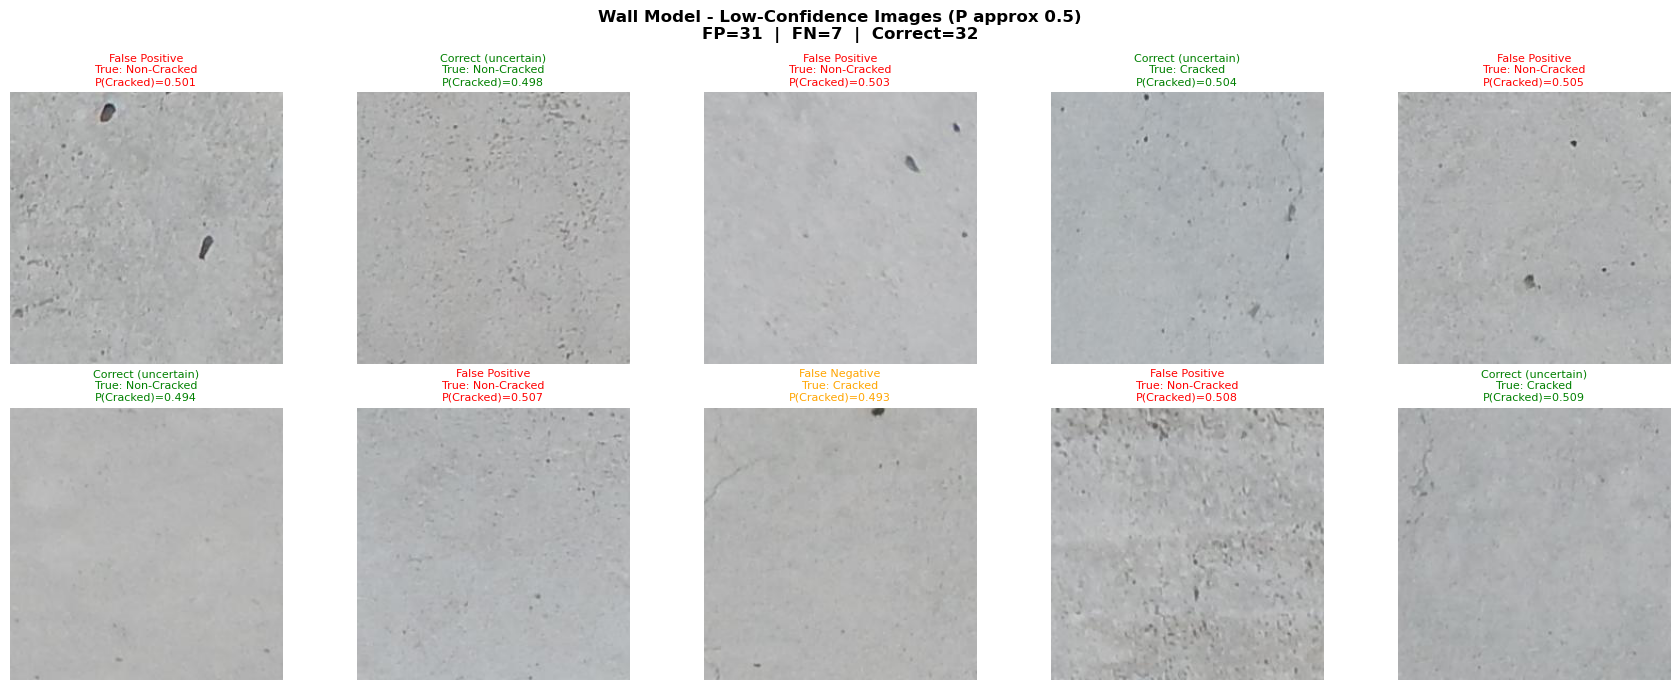

([np.int64(2227),
  np.int64(2619),
  np.int64(2793),
  np.int64(4459),
  np.int64(1410),
  np.int64(3250),
  np.int64(6049),
  np.int64(4897),
  np.int64(7520),
  np.int64(3464),
  np.int64(4501),
  np.int64(2215),
  np.int64(4589),
  np.int64(13172),
  np.int64(13227),
  np.int64(3138),
  np.int64(13224),
  np.int64(15586),
  np.int64(6005),
  np.int64(3338),
  np.int64(2877),
  np.int64(3173),
  np.int64(241),
  np.int64(1388),
  np.int64(3152),
  np.int64(7309),
  np.int64(13058),
  np.int64(835),
  np.int64(2311),
  np.int64(151),
  np.int64(5666),
  np.int64(5582),
  np.int64(2712),
  np.int64(437),
  np.int64(2263),
  np.int64(11578),
  np.int64(2896),
  np.int64(956)],
 [(0.5013946890830994,
   array([[[172, 174, 173],
           [174, 176, 175],
           [174, 176, 175],
           ...,
           [185, 185, 183],
           [192, 192, 190],
           [196, 196, 194]],
   
          [[172, 174, 173],
           [172, 174, 173],
           [171, 173, 172],
           ...,
  

In [24]:
# Wall model – low-confidence images from the test set (probability within ±0.1 of 0.5)
show_low_confidence_images(model_walls, walls_te, device, tolerance=0.05, n_show=10, dataset_name="Wall Model")

Deck Model: 66 low-confidence images (P within +/-0.05 of 0.5)
  False Positives  (predicted Cracked,     actually Non-Cracked): 16
  False Negatives  (predicted Non-Cracked, actually Cracked):     20
  Correct but uncertain:                                           30


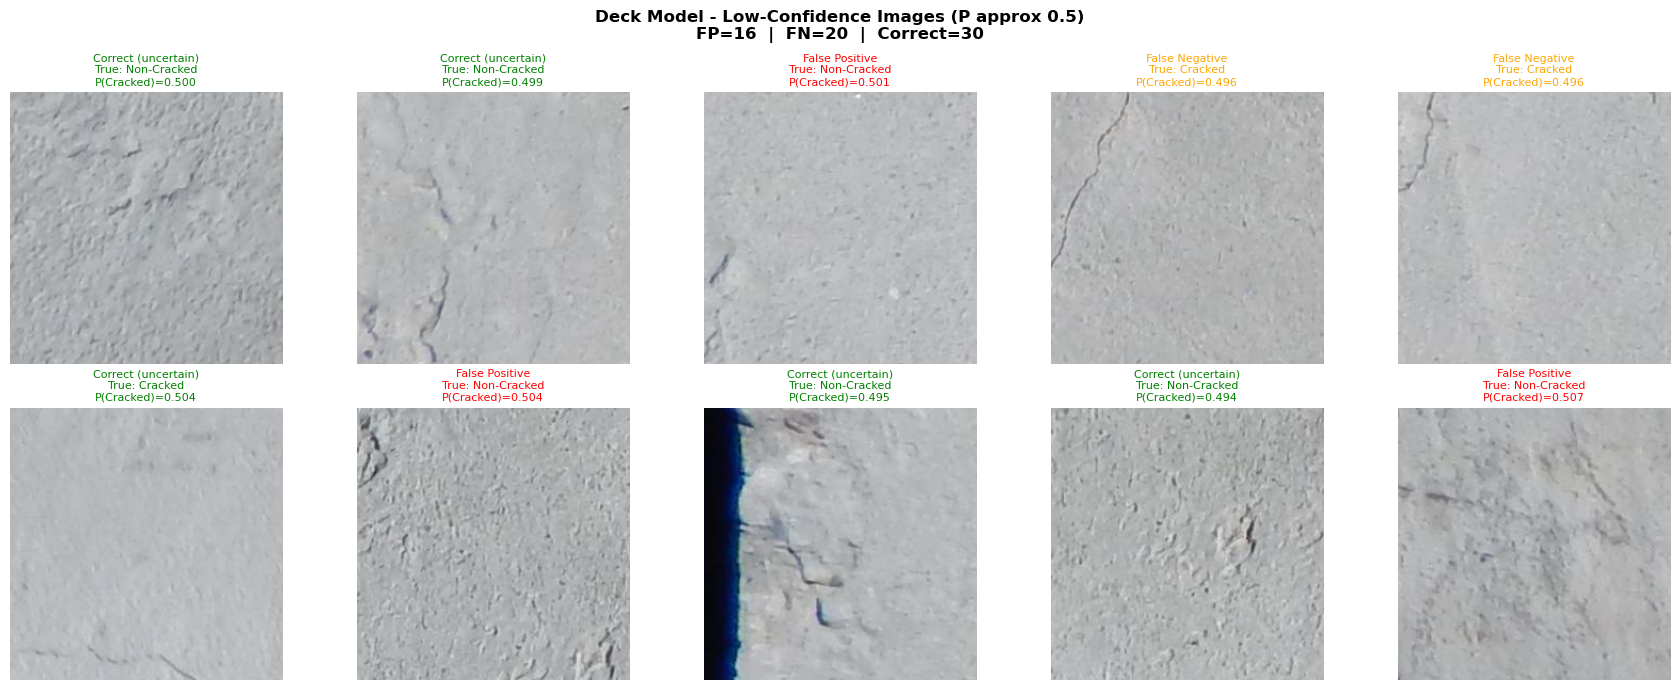

([np.int64(8249),
  np.int64(403),
  np.int64(509),
  np.int64(11328),
  np.int64(10937),
  np.int64(103),
  np.int64(122),
  np.int64(9341),
  np.int64(9620),
  np.int64(687),
  np.int64(2296),
  np.int64(699),
  np.int64(378),
  np.int64(7426),
  np.int64(7157),
  np.int64(252),
  np.int64(12936),
  np.int64(1676),
  np.int64(1600),
  np.int64(11861),
  np.int64(10370),
  np.int64(9726),
  np.int64(1698),
  np.int64(3247),
  np.int64(1478),
  np.int64(1642),
  np.int64(683),
  np.int64(3047),
  np.int64(10920),
  np.int64(1617),
  np.int64(1652),
  np.int64(1484),
  np.int64(1513),
  np.int64(9149),
  np.int64(1180),
  np.int64(1612)],
 [(0.4996486306190491,
   array([[[176, 177, 179],
           [178, 179, 181],
           [178, 179, 181],
           ...,
           [182, 183, 185],
           [174, 175, 177],
           [177, 178, 180]],
   
          [[176, 177, 179],
           [176, 177, 179],
           [175, 176, 178],
           ...,
           [182, 183, 185],
           [17

In [17]:
# Deck model – low-confidence images from the test set (probability within ±0.1 of 0.5)
show_low_confidence_images(model_decks, decks_te, device, tolerance=0.05, n_show=10, dataset_name="Deck Model")

#### Remove Low-Confidence Misclassifications and Retrain

Collect the FP and FN indices identified across all splits of each dataset, remove them from the full cleaned dataframes, re-split, and retrain fresh models from scratch.

In [18]:
def collect_low_conf_misclassified_indices(model, df_full, device, tolerance=0.1):
    """Scan an entire dataframe and return the original df indices of FP and FN images
    where the model's confidence is within `tolerance` of 0.5."""
    model.eval()
    flagged = []

    for idx in range(len(df_full)):
        row = df_full.iloc[idx]
        image = row['ImageData'].astype(np.float32) / 255.0

        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)

        img_tensor = torch.from_numpy(np.transpose(image, (2, 0, 1))).unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(img_tensor)).item()

        if abs(prob - 0.5) <= tolerance:
            true_label = row['Label']
            predicted = 'Cracked' if prob >= 0.5 else 'Non-Cracked'

            # Only flag actual misclassifications (FP or FN), not correct uncertain predictions
            if true_label != predicted:
                flagged.append(df_full.index[idx])

    return flagged

In [19]:
# Scan the full cleaned datasets for low-confidence misclassifications
print("Scanning Wall dataset...")
fn_fp_walls = collect_low_conf_misclassified_indices(model_walls, df_walls, device, tolerance=0.1)
print(f"  Found {len(fn_fp_walls)} low-confidence misclassified images to remove")

print("\nScanning Deck dataset...")
fn_fp_decks = collect_low_conf_misclassified_indices(model_decks, df_decks, device, tolerance=0.1)
print(f"  Found {len(fn_fp_decks)} low-confidence misclassified images to remove")

# Remove flagged images and save further-cleaned datasets
df_walls_v2 = df_walls.drop(index=fn_fp_walls).reset_index(drop=True)
df_decks_v2 = df_decks.drop(index=fn_fp_decks).reset_index(drop=True)

print(f"\nWall dataset:  {len(df_walls)} -> {len(df_walls_v2)} images  (removed {len(fn_fp_walls)})")
print(f"  Label distribution: {df_walls_v2['Label'].value_counts().to_dict()}")
print(f"\nDeck dataset:  {len(df_decks)} -> {len(df_decks_v2)} images  (removed {len(fn_fp_decks)})")
print(f"  Label distribution: {df_decks_v2['Label'].value_counts().to_dict()}")

# Re-split into train / val / test
walls_v2, walls_te_v2 = train_test_split(df_walls_v2, test_size=0.2, random_state=42, stratify=df_walls_v2['Label'])
walls_tr_v2, walls_val_v2 = train_test_split(walls_v2, test_size=0.176, random_state=42, stratify=walls_v2['Label'])

decks_v2, decks_te_v2 = train_test_split(df_decks_v2, test_size=0.2, random_state=42, stratify=df_decks_v2['Label'])
decks_tr_v2, decks_val_v2 = train_test_split(decks_v2, test_size=0.176, random_state=42, stratify=decks_v2['Label'])

# Recreate data loaders
pin_memory = torch.cuda.is_available()

pos_weight_walls_v2 = calculate_pos_weight(walls_tr_v2, label_map)
criterion_walls_v2 = nn.BCEWithLogitsLoss(pos_weight=pos_weight_walls_v2.to(device))

train_loader_walls_v2 = DataLoader(CrackDataset(walls_tr_v2,  label_map), batch_size=32, shuffle=True,  num_workers=0, pin_memory=pin_memory)
val_loader_walls_v2   = DataLoader(CrackDataset(walls_val_v2, label_map), batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_walls_v2  = DataLoader(CrackDataset(walls_te_v2,  label_map), batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

pos_weight_decks_v2 = calculate_pos_weight(decks_tr_v2, label_map)
criterion_decks_v2  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_decks_v2.to(device))

train_loader_decks_v2 = DataLoader(CrackDataset(decks_tr_v2,  label_map), batch_size=32, shuffle=True,  num_workers=0, pin_memory=pin_memory)
val_loader_decks_v2   = DataLoader(CrackDataset(decks_val_v2, label_map), batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_decks_v2  = DataLoader(CrackDataset(decks_te_v2,  label_map), batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

print(f"\nWalls pos_weight: {pos_weight_walls_v2.item():.4f}")
print(f"Decks pos_weight: {pos_weight_decks_v2.item():.4f}")
print("Data loaders ready.")

Scanning Wall dataset...
  Found 459 low-confidence misclassified images to remove

Scanning Deck dataset...
  Found 326 low-confidence misclassified images to remove

Wall dataset:  16210 -> 15751 images  (removed 459)
  Label distribution: {'Non-Cracked': 13840, 'Cracked': 1911}

Deck dataset:  13218 -> 12892 images  (removed 326)
  Label distribution: {'Non-Cracked': 11359, 'Cracked': 1533}

Walls pos_weight: 7.2397
Decks pos_weight: 7.4129
Data loaders ready.


#### Retrain Wall Model on Further-Cleaned Data

In [20]:
print("Wall Model – Retraining on further-cleaned data...\n")
model_walls_v2 = CNNBinary().to(device)
optimizer_walls_v2 = optim.Adam(model_walls_v2.parameters(), lr=1e-4)
scheduler_walls_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_walls_v2, mode='max', factor=0.5, patience=2, min_lr=1e-6)

history_walls_v2 = train_model(
    model_walls_v2,
    train_loader_walls_v2,
    val_loader_walls_v2,
    optimizer_walls_v2,
    criterion_walls_v2,
    device,
    epochs=300,
    patience=5,
    scheduler=scheduler_walls_v2)

Wall Model – Retraining on further-cleaned data...

Epoch 1/300 - train_loss: 1.1042, train_f1: 0.3389, train_recall:0.7063 | val_loss: 0.9633, val_f1: 0.3878, val_recall:0.7807 | lr: 0.000100
Epoch 2/300 - train_loss: 0.9398, train_f1: 0.3847, train_recall:0.7913 | val_loss: 0.8767, val_f1: 0.4051, val_recall:0.8290 | lr: 0.000100
Epoch 3/300 - train_loss: 0.8516, train_f1: 0.4165, train_recall:0.8222 | val_loss: 0.8187, val_f1: 0.3789, val_recall:0.8959 | lr: 0.000100
Epoch 4/300 - train_loss: 0.8119, train_f1: 0.4368, train_recall:0.8270 | val_loss: 0.7684, val_f1: 0.4268, val_recall:0.8773 | lr: 0.000100
Epoch 5/300 - train_loss: 0.7652, train_f1: 0.4551, train_recall:0.8198 | val_loss: 0.7851, val_f1: 0.4256, val_recall:0.8401 | lr: 0.000100
Epoch 6/300 - train_loss: 0.7408, train_f1: 0.4676, train_recall:0.8468 | val_loss: 0.7272, val_f1: 0.5858, val_recall:0.6914 | lr: 0.000100
Epoch 7/300 - train_loss: 0.6929, train_f1: 0.5175, train_recall:0.8262 | val_loss: 0.7090, val_f1: 0.

#### Retrain Deck Model on Further-Cleaned Data

In [21]:
print("Deck Model – Retraining on further-cleaned data...\n")
model_decks_v2 = CNNBinary().to(device)
optimizer_decks_v2 = optim.Adam(model_decks_v2.parameters(), lr=1e-4)
scheduler_decks_v2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_decks_v2, mode='max', factor=0.5, patience=2, min_lr=1e-6)

history_decks_v2 = train_model(
    model_decks_v2,
    train_loader_decks_v2,
    val_loader_decks_v2,
    optimizer_decks_v2,
    criterion_decks_v2,
    device,
    epochs=300,
    patience=5,
    scheduler=scheduler_decks_v2)

Deck Model – Retraining on further-cleaned data...

Epoch 1/300 - train_loss: 1.1842, train_f1: 0.2402, train_recall:0.9198 | val_loss: 1.0974, val_f1: 0.3173, val_recall:0.7500 | lr: 0.000100
Epoch 2/300 - train_loss: 1.0856, train_f1: 0.3031, train_recall:0.7238 | val_loss: 1.1745, val_f1: 0.2496, val_recall:0.9815 | lr: 0.000100
Epoch 3/300 - train_loss: 1.0316, train_f1: 0.3268, train_recall:0.6911 | val_loss: 0.9766, val_f1: 0.4514, val_recall:0.5370 | lr: 0.000100
Epoch 4/300 - train_loss: 0.9946, train_f1: 0.3504, train_recall:0.7109 | val_loss: 0.9331, val_f1: 0.3759, val_recall:0.7361 | lr: 0.000100
Epoch 5/300 - train_loss: 0.9685, train_f1: 0.3709, train_recall:0.7119 | val_loss: 0.9240, val_f1: 0.4729, val_recall:0.6065 | lr: 0.000100
Epoch 6/300 - train_loss: 0.9422, train_f1: 0.3905, train_recall:0.7178 | val_loss: 1.1150, val_f1: 0.4695, val_recall:0.3565 | lr: 0.000100
Epoch 7/300 - train_loss: 0.9155, train_f1: 0.4039, train_recall:0.6980 | val_loss: 0.9837, val_f1: 0.

#### Evaluate Retrained Models (v2)

Test Set Evaluation - Walls Dataset (v2)

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.97      0.95      0.96      2769
     Cracked       0.67      0.76      0.71       382

    accuracy                           0.93      3151
   macro avg       0.82      0.85      0.83      3151
weighted avg       0.93      0.93      0.93      3151



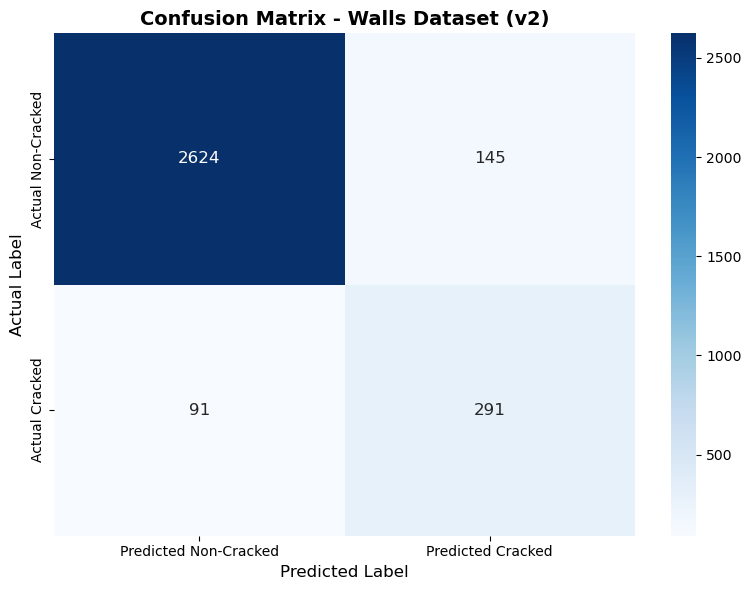

Test Set Evaluation - Decks Dataset (v2)

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.94      0.97      0.95      2272
     Cracked       0.69      0.55      0.62       307

    accuracy                           0.92      2579
   macro avg       0.82      0.76      0.78      2579
weighted avg       0.91      0.92      0.91      2579



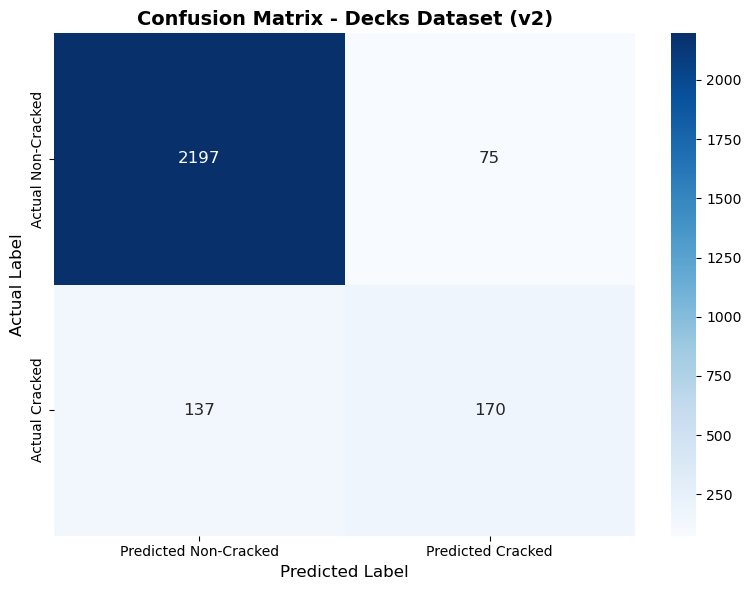

In [22]:
cm_walls_v2, report_walls_v2, preds_walls_v2, labels_walls_v2 = evaluate_model(
    model_walls_v2, test_loader_walls_v2, device, threshold=0.5, dataset_name="Walls Dataset (v2)")

cm_decks_v2, report_decks_v2, preds_decks_v2, labels_decks_v2 = evaluate_model(
    model_decks_v2, test_loader_decks_v2, device, threshold=0.5, dataset_name="Decks Dataset (v2)")